# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Muhammad Rafi Reshad F
- **Email:** mrafi.reshad@gmail.com
- **ID Dicoding:** cdcc200d6y2234

## Menentukan Pertanyaan Bisnis

- Apakah permintaan sepeda menunjukkan tren pertumbuhan atau penurunan yang berdampak pada keputusan ekspansi bisnis?
- Apakah kenaikan suhu secara konsisten meningkatkan permintaan sepeda?
- Apakah kondisi angin menjadi faktor penghambat signifikan dalam penggunaan sepeda?
- Secara rata rata di jam berapa biasanya permintaan sepeda tertinggi?
- Secara rata rata di hari apa biasanya permintaan sepeda tertinggi?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [ ]:
df_day=pd.read_csv("data\day.csv")
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [ ]:
df_hour=pd.read_csv('data\hour.csv')
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dua Granularitas: terdapat data level harian (df_day) untuk tren umum dan level per jam (df_hour) untuk melihat jam sibuk (peak hours).

- Segmentasi Pengguna: Kolom casual dan registered menunjukkan ada dua tipe penyewa. Biasanya, pengguna terdaftar lebih mendominasi pada hari kerja.

- Variabel Terukur: Cuaca (weathersit), suhu (temp), dan kelembapan (hum) sudah dalam bentuk angka ternormalisasi (0-1), siap untuk dianalisis korelasinya dengan jumlah sewa (cnt).

- Pola Waktu: Data per jam menunjukkan aktivitas sangat rendah di dini hari (jam 00:00 - 04:00), yang menandakan pola penggunaan transportasi publik/komuter yang normal.

### Assessing Data

In [52]:
df_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [53]:
print("Jumlah Duplikat :", df_day.duplicated().sum())
df_day.describe()

Jumlah Duplikat : 0


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [54]:
df_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [55]:
print("Jumlah Duplikasi :", df_hour.duplicated().sum())
df_hour.describe()

Jumlah Duplikasi : 0


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Data Bersih dari Missing Values karena semua kolom memiliki jumlah non-null yang sama yaitu 731 di harian dan 17.379 di jam, artinya tidak ada data yang kosong.

- Tidak Ada Duplikat karena hasil duplicated().sum() adalah 0

- Rentang Data Logis, dapat dilihat pada df_hour, nilai hr (jam) berkisar antara 0-23, dan temp (suhu) antara 0-1 (sudah dinormalisasi). Nilai maksimum penyewa (cnt) mencapai 977 per jam.

- Kesalahan Tipe Data (dteday) yaitu Kolom dteday yang saat ini adalah bertipe object (string) sehingga harus diubah ke tipe datetime. Jika tidak diubah, tidak bisa dilakukan analisis tren waktu (seperti per bulan atau per minggu) dengan benar.

### Cleaning Data

In [56]:
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])
print(df_hour.dtypes)

instant                int64
dteday        datetime64[ns]
season                 int64
yr                     int64
mnth                   int64
hr                     int64
holiday                int64
weekday                int64
workingday             int64
weathersit             int64
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
dtype: object


In [57]:
df_day['dteday'] = pd.to_datetime(df_day['dteday'])
print(df_day.dtypes)

instant                int64
dteday        datetime64[ns]
season                 int64
yr                     int64
mnth                   int64
holiday                int64
weekday                int64
workingday             int64
weathersit             int64
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
dtype: object


**Insight:**
- Tipe data dteday telah dirubah menjadi datetime yang sebelumnya bertipa object sehingga lebih mudah dilakukan visualisai
- Tidak terdapat nilai duplikat dan missing value sehingga tidak diperlukan penanganan untuk kedua masalah tersebut

## Exploratory Data Analysis (EDA)

### Explore ...

In [58]:
df_hour.describe(include="all")


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


In [59]:
df_day.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


In [60]:
hourly_avg_cnt = df_hour.groupby('hr')['cnt'].mean()

print("\nRata-rata jumlah sewa per jam:")
print(hourly_avg_cnt)


Rata-rata jumlah sewa per jam:
hr
0      53.898072
1      33.375691
2      22.869930
3      11.727403
4       6.352941
5      19.889819
6      76.044138
7     212.064649
8     359.011004
9     219.309491
10    173.668501
11    208.143054
12    253.315934
13    253.661180
14    240.949246
15    251.233196
16    311.983562
17    461.452055
18    425.510989
19    311.523352
20    226.030220
21    172.314560
22    131.335165
23     87.831044
Name: cnt, dtype: float64


In [61]:
# Agregasi permintaan sepeda per tahun
demand_by_year = df_day.groupby('yr')['cnt'].mean().reset_index()

# Agregasi permintaan sepeda per bulan
demand_by_month = df_day.groupby('mnth')['cnt'].mean().reset_index()

# Agregasi permintaan sepeda per hari dalam seminggu
demand_by_weekday = df_day.groupby('weekday')['cnt'].mean().reset_index()

# Agregasi permintaan sepeda per jam
demand_by_hour = df_hour.groupby('hr')['cnt'].mean().reset_index()

print("Rata-rata permintaan sepeda per tahun:")
print(demand_by_year)
print("\nRata-rata permintaan sepeda per bulan:")
print(demand_by_month)
print("\nRata-rata permintaan sepeda per hari dalam seminggu:")
print(demand_by_weekday)
print("\nRata-rata permintaan sepeda per jam:")
print(demand_by_hour)

Rata-rata permintaan sepeda per tahun:
   yr          cnt
0   0  3405.761644
1   1  5599.934426

Rata-rata permintaan sepeda per bulan:
    mnth          cnt
0      1  2176.338710
1      2  2655.298246
2      3  3692.258065
3      4  4484.900000
4      5  5349.774194
5      6  5772.366667
6      7  5563.677419
7      8  5664.419355
8      9  5766.516667
9     10  5199.225806
10    11  4247.183333
11    12  3403.806452

Rata-rata permintaan sepeda per hari dalam seminggu:
   weekday          cnt
0        0  4228.828571
1        1  4338.123810
2        2  4510.663462
3        3  4548.538462
4        4  4667.259615
5        5  4690.288462
6        6  4550.542857

Rata-rata permintaan sepeda per jam:
    hr         cnt
0    0   53.898072
1    1   33.375691
2    2   22.869930
3    3   11.727403
4    4    6.352941
5    5   19.889819
6    6   76.044138
7    7  212.064649
8    8  359.011004
9    9  219.309491
10  10  173.668501
11  11  208.143054
12  12  253.315934
13  13  253.661180
14  14  2

### Pola Penggunaan Sepeda oleh Pengguna Casual vs Registered

In [62]:
# Analisis permintaan casual dan registered berdasarkan workingday (dari df_day)
demand_by_workingday_users = df_day.groupby('workingday')[['casual', 'registered', 'cnt']].mean().reset_index()

# Analisis permintaan casual dan registered berdasarkan weekday (dari df_day)
demand_by_weekday_users = df_day.groupby('weekday')[['casual', 'registered', 'cnt']].mean().reset_index()

# Analisis permintaan casual dan registered berdasarkan jam (dari df_hour)
demand_by_hour_users = df_hour.groupby('hr')[['casual', 'registered', 'cnt']].mean().reset_index()

print("Rata-rata permintaan casual dan registered berdasarkan hari kerja/libur:")
print(demand_by_workingday_users)

print("\nRata-rata permintaan casual dan registered berdasarkan hari dalam seminggu:")
print(demand_by_weekday_users)

print("\nRata-rata permintaan casual dan registered berdasarkan jam:")
print(demand_by_hour_users)

Rata-rata permintaan casual dan registered berdasarkan hari kerja/libur:
   workingday       casual   registered          cnt
0           0  1371.134199  2959.034632  4330.168831
1           1   606.570000  3978.250000  4584.820000

Rata-rata permintaan casual dan registered berdasarkan hari dalam seminggu:
   weekday       casual   registered          cnt
0        0  1338.295238  2890.533333  4228.828571
1        1   674.133333  3663.990476  4338.123810
2        2   556.182692  3954.480769  4510.663462
3        3   551.144231  3997.394231  4548.538462
4        4   590.961538  4076.298077  4667.259615
5        5   752.288462  3938.000000  4690.288462
6        6  1465.257143  3085.285714  4550.542857

Rata-rata permintaan casual dan registered berdasarkan jam:
    hr     casual  registered         cnt
0    0  10.158402   43.739669   53.898072
1    1   6.504144   26.871547   33.375691
2    2   4.772028   18.097902   22.869930
3    3   2.715925    9.011478   11.727403
4    4   1.253945   

**Insight:**
- **Tren Pertumbuhan Tahunan:** Permintaan sepeda menunjukkan tren pertumbuhan yang signifikan dari tahun 2011 ke 2012 (dari rata-rata 3405 menjadi 5599), yang mendukung keputusan ekspansi bisnis.
- **Pola Musiman:** Permintaan sepeda mencapai puncaknya pada bulan-bulan pertengahan tahun (Mei-September) dan cenderung rendah di awal dan akhir tahun (Januari, Februari, Desember).
- **Permintaan Harian Keseluruhan:** Permintaan cukup konsisten sepanjang hari dalam seminggu, dengan sedikit peningkatan pada hari Jumat dan Sabtu.
- **Pola Permintaan Per Jam Keseluruhan:** Terdapat dua puncak permintaan utama, yaitu pada jam 8 pagi dan jam 5-6 sore, yang kemungkinan terkait dengan jam berangkat dan pulang kerja/sekolah.
- **Pola Penggunaan Casual vs Registered:**
    - Pengguna **kasual** mendominasi pada akhir pekan dan hari libur, serta di siang hari, menunjukkan penggunaan untuk rekreasi.
    - Pengguna **terdaftar** mendominasi pada hari kerja dan jam-jam sibuk pagi/sore, menunjukkan penggunaan untuk *commuting*.

## Visualization & Explanatory Analysis

### Apakah permintaan sepeda menunjukkan tren pertumbuhan atau penurunan?

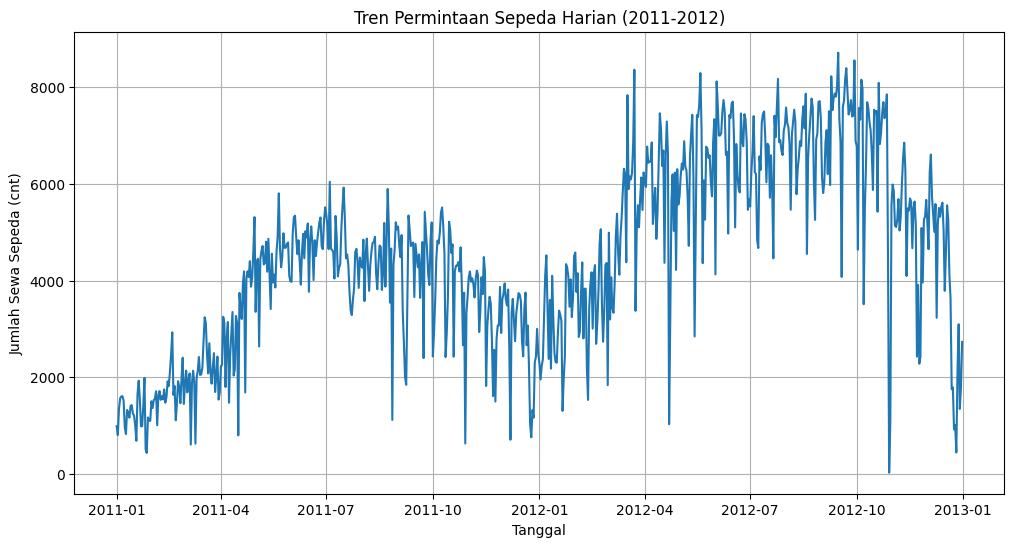

In [63]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='dteday', y='cnt', data=df_day)
plt.title('Tren Permintaan Sepeda Harian (2011-2012)')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Sewa Sepeda (cnt)')
plt.grid(True)
plt.show()

### Apakah kenaikan suhu secara konsisten meningkatkan permintaan sepeda?

Korelasi antara suhu dan total sewa: 0.63


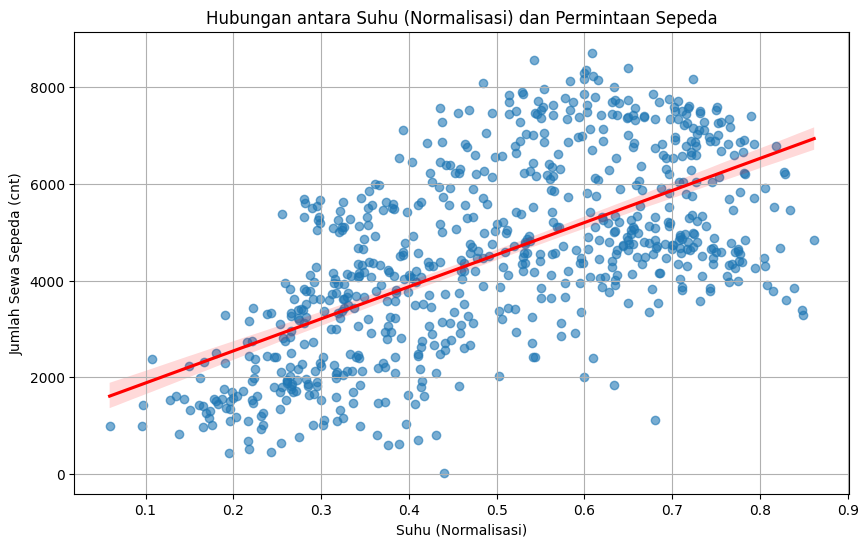

In [64]:
# Hitung korelasi antara suhu (temp) dengan jumlah sewa (cnt)
correlation_temp = df_day['temp'].corr(df_day['cnt'])
print(f"Korelasi antara suhu dan total sewa: {correlation_temp:.2f}")

plt.figure(figsize=(10, 6))
sns.regplot(x='temp', y='cnt', data=df_day, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Hubungan antara Suhu (Normalisasi) dan Permintaan Sepeda')
plt.xlabel('Suhu (Normalisasi)')
plt.ylabel('Jumlah Sewa Sepeda (cnt)')
plt.grid(True)
plt.show()

### Apakah kondisi angin menjadi faktor penghambat signifikan dalam penggunaan sepeda?

Korelasi antara kecepatan angin dan total sewa: -0.23


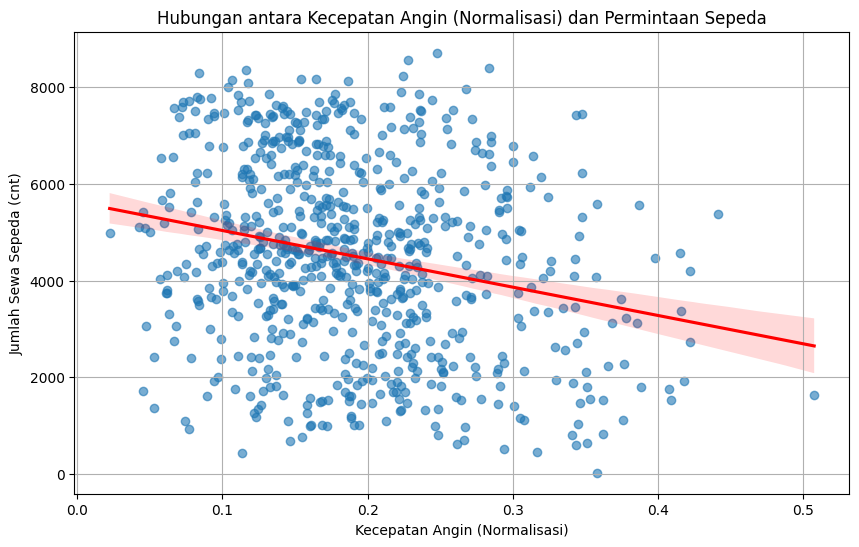

In [65]:
# Hitung korelasi antara kecepatan angin (windspeed) dengan jumlah sewa (cnt)
correlation_windspeed = df_day['windspeed'].corr(df_day['cnt'])
print(f"Korelasi antara kecepatan angin dan total sewa: {correlation_windspeed:.2f}")

plt.figure(figsize=(10, 6))
sns.regplot(x='windspeed', y='cnt', data=df_day, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Hubungan antara Kecepatan Angin (Normalisasi) dan Permintaan Sepeda')
plt.xlabel('Kecepatan Angin (Normalisasi)')
plt.ylabel('Jumlah Sewa Sepeda (cnt)')
plt.grid(True)
plt.show()

### Secara rata rata di jam berapa biasanya permintaan sepeda tertinggi?

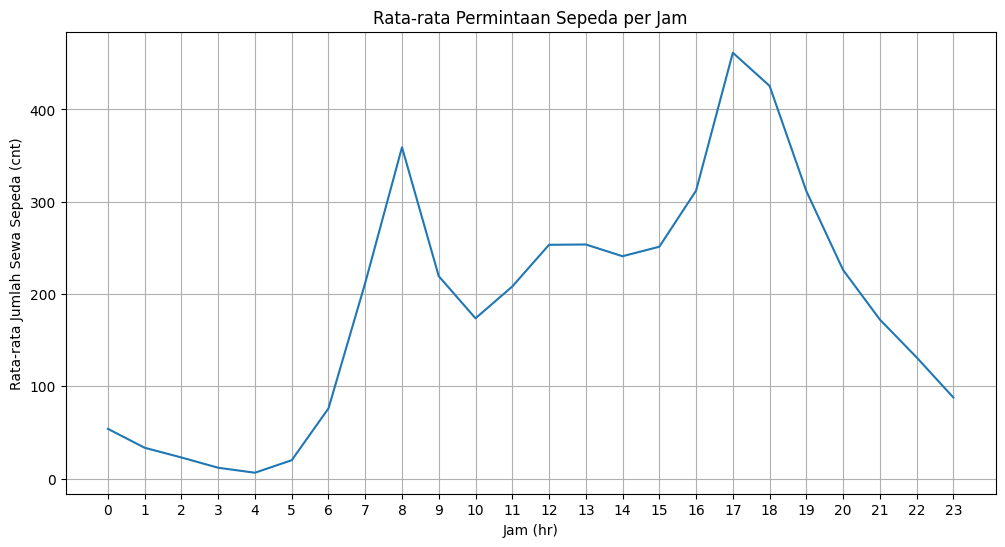

In [66]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='hr', y='cnt', data=demand_by_hour)
plt.title('Rata-rata Permintaan Sepeda per Jam')
plt.xlabel('Jam (hr)')
plt.ylabel('Rata-rata Jumlah Sewa Sepeda (cnt)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

### Secara rata rata di hari apa biasanya permintaan sepeda tertinggi?

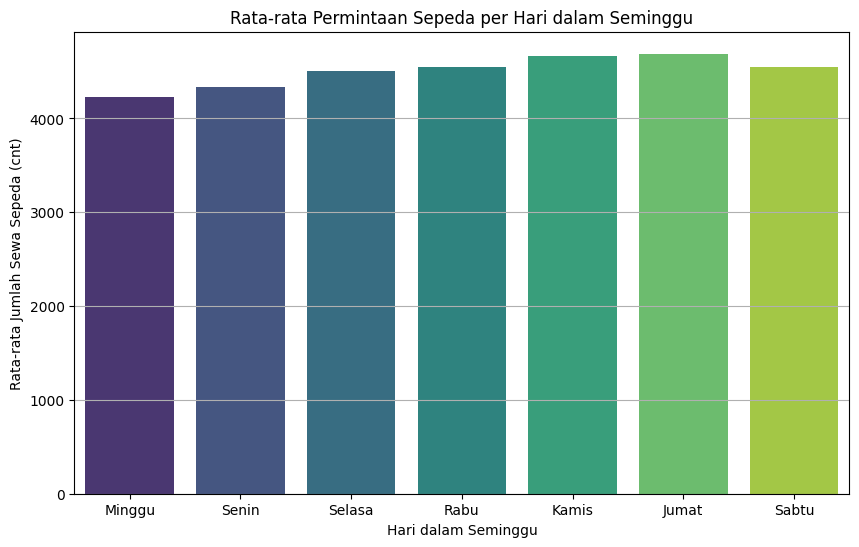

In [67]:
day_names = ['Minggu', 'Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu']
demand_by_weekday['weekday_label'] = demand_by_weekday['weekday'].map(lambda x: day_names[x])

plt.figure(figsize=(10, 6))
sns.barplot(x='weekday_label', y='cnt', hue='weekday_label', data=demand_by_weekday, palette='viridis', legend=False)
plt.title('Rata-rata Permintaan Sepeda per Hari dalam Seminggu')
plt.xlabel('Hari dalam Seminggu')
plt.ylabel('Rata-rata Jumlah Sewa Sepeda (cnt)')
plt.grid(axis='y')
plt.show()

**Insight:**
- Visualisasi line chart pertama menunjukkan tren permintaan sepeda yang meningkat secara signifikan dari tahun 2011 ke 2012. Ini mengindikasikan pertumbuhan yang kuat dan mendukung potensi ekspansi bisnis.
- Terdapat korelasi positif yang cukup kuat antara suhu dan jumlah sewa sepeda. hal ini dapat dilihat pada scatterplot di visualisasi kedua yang titik titik datanya berada disekitar garis regresi.Ini menunjukkan bahwa kenaikan suhu secara konsisten meningkatkan permintaan sepeda, menandakan bahwa cuaca hangat adalah faktor penting yang mendorong penggunaan sepeda.
- Terdapat korelasi negatif yang lemah antara kecepatan angin dan jumlah sewa sepeda hal ini dapat dilihat pada scatterplot di visualisasi kedua yang titik titik datanya menyebar acak disekitar garis regresi. Ini mengindikasikan bahwa kondisi angin kencang dapat menjadi faktor penghambat, meskipun tidak signifikan, dalam penggunaan sepeda.
- Permintaan sepeda mencapai puncaknya dua kali sehari, yaitu sekitar jam 8 pagi dan antara jam 5 sore hingga 6 sore. Pola ini sangat konsisten dengan jam berangkat dan pulang kerja/sekolah, menunjukkan bahwa banyak pengguna memanfaatkan sepeda untuk keperluan komuter harian.
- Permintaan sepeda relatif konsisten sepanjang hari dalam seminggu, dengan sedikit peningkatan pada hari Jumat dan Sabtu. Ini menunjukkan bahwa sepeda digunakan secara merata baik untuk aktivitas harian maupun rekreasi akhir pekan.

## Analisis Lanjutan (Opsional)

### Clustering Analisis Harian

In [68]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Pilih fitur-fitur yang akan digunakan untuk clustering dari df_day
features = ['temp', 'atemp', 'hum', 'windspeed', 'weathersit', 'cnt']
X = df_day[features]

# Standardisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Tentukan jumlah cluster (k). Kita bisa mencoba beberapa nilai k untuk menemukan yang optimal nanti.
k = 4 # Sebagai contoh, kita mulai dengan 4 cluster

# Terapkan K-Means clustering
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init untuk mengatasi inisialisasi acak
df_day['cluster'] = kmeans.fit_predict(X_scaled)

print("Distribusi anggota cluster:")
print(df_day['cluster'].value_counts())

# Lihat rata-rata fitur per cluster
print("\nRata-rata fitur per cluster:")
print(df_day.groupby('cluster')[features].mean())


Distribusi anggota cluster:
cluster
3    262
1    208
2    132
0    129
Name: count, dtype: int64

Rata-rata fitur per cluster:
             temp     atemp       hum  windspeed  weathersit          cnt
cluster                                                                  
0        0.332207  0.330384  0.729458   0.208647    2.124031  2588.116279
1        0.326308  0.325060  0.517061   0.216071    1.033654  3451.028846
2        0.604934  0.571370  0.759712   0.171951    2.030303  5100.606061
3        0.654764  0.614885  0.599465   0.170571    1.003817  5983.656489


Sekarang, mari kita visualisasikan hasil clustering. Kita bisa melihat bagaimana rata-rata fitur bervariasi antar cluster. Saya akan membuat bar plot untuk membandingkan rata-rata `cnt`, `temp`, dan `weathersit` di setiap cluster.

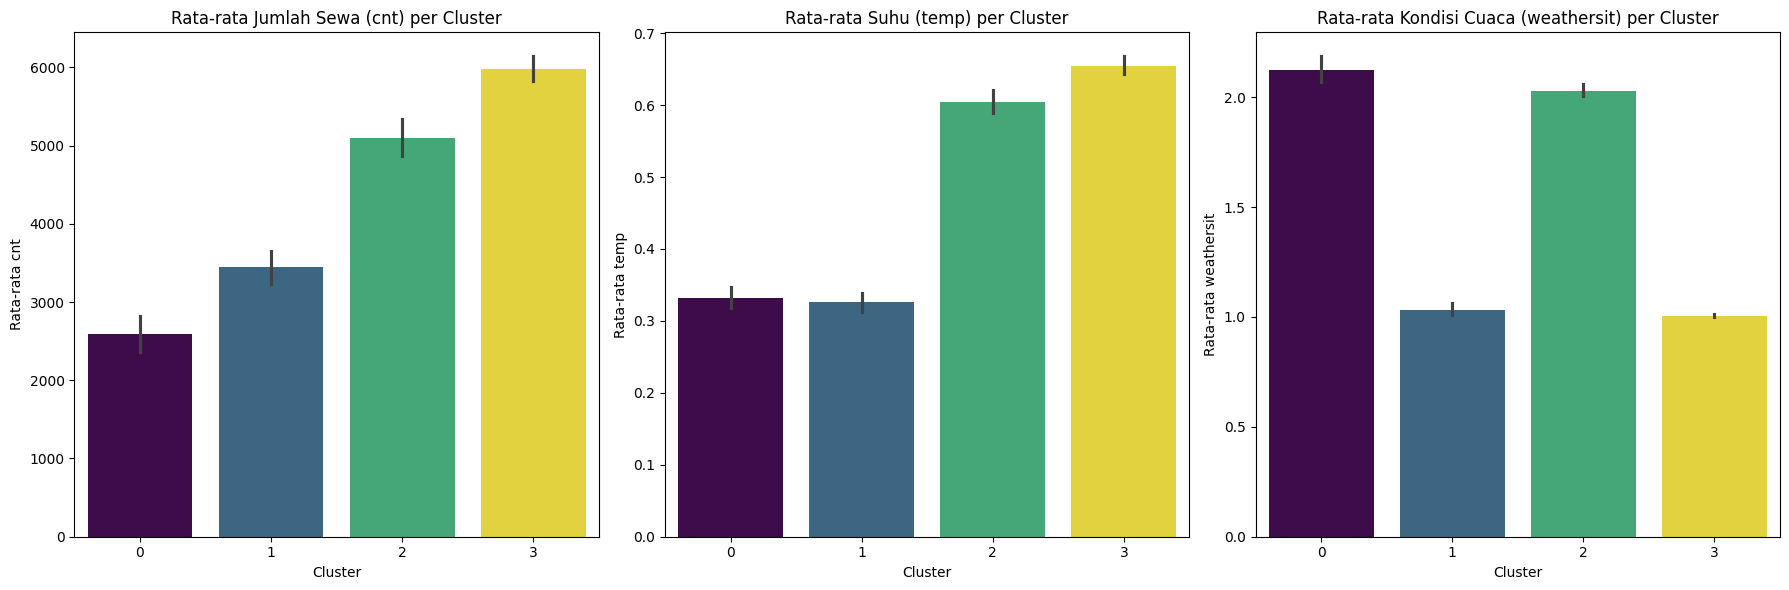

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(x='cluster', y='cnt', data=df_day, ax=axes[0], hue='cluster', palette='viridis', legend=False)
axes[0].set_title('Rata-rata Jumlah Sewa (cnt) per Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Rata-rata cnt')

sns.barplot(x='cluster', y='temp', data=df_day, ax=axes[1], hue='cluster', palette='viridis', legend=False)
axes[1].set_title('Rata-rata Suhu (temp) per Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Rata-rata temp')

sns.barplot(x='cluster', y='weathersit', data=df_day, ax=axes[2], hue='cluster', palette='viridis', legend=False)
axes[2].set_title('Rata-rata Kondisi Cuaca (weathersit) per Cluster')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Rata-rata weathersit')

plt.tight_layout()
plt.show()


Untuk menentukan jumlah cluster yang optimal, kita bisa menggunakan **Elbow Method**:

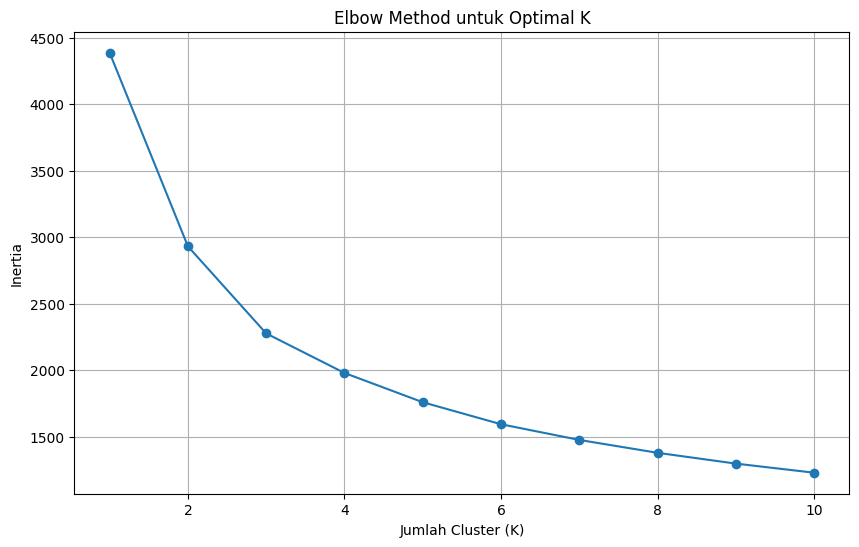

In [70]:
inertia = []
range_k = range(1, 11)

for i in range_k:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range_k, inertia, marker='o')
plt.title('Elbow Method untuk Optimal K')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()



## Analisis Lanjutan: Clustering (Manual Grouping & Binning)

### 1. Clustering: Pengelompokan Manual Berdasarkan Kondisi Cuaca (`weathersit`)

Rata-rata fitur per kelompok cuaca:
   weathersit_label          cnt      temp       hum  windspeed
0  Clear/Few clouds  4876.786177  0.511541  0.565594   0.190253
1   Light Rain/Snow  1803.285714  0.433440  0.848872   0.243336
2       Mist/Cloudy  4035.862348  0.470366  0.725887   0.186431


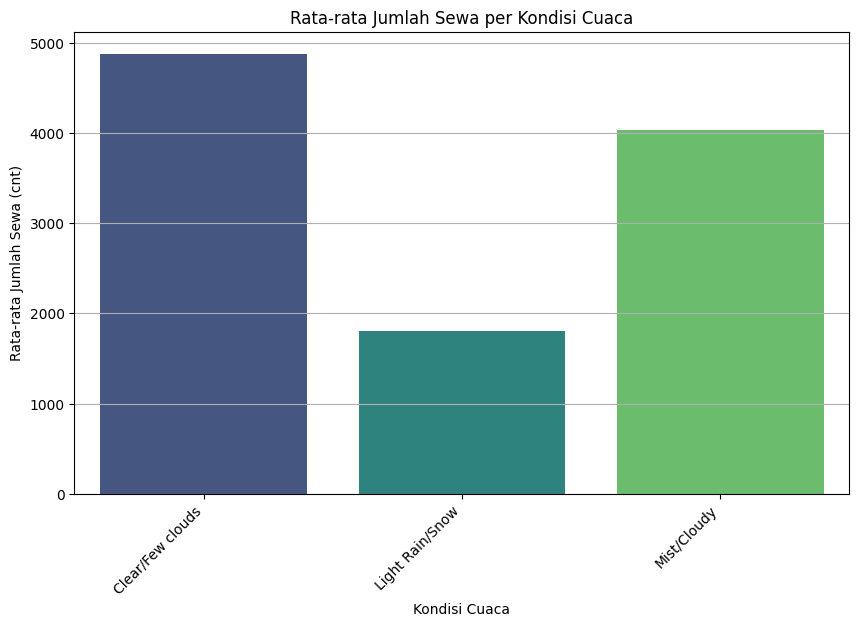

In [71]:
# Map nilai weathersit ke label yang lebih deskriptif
weathersit_labels = {
    1: 'Clear/Few clouds',
    2: 'Mist/Cloudy',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Snow'
}
df_day['weathersit_label'] = df_day['weathersit'].map(weathersit_labels)

# Kelompokkan data berdasarkan weathersit_label dan hitung rata-rata fitur relevan
weather_clusters = df_day.groupby('weathersit_label')[['cnt', 'temp', 'hum', 'windspeed']].mean().reset_index()

print("Rata-rata fitur per kelompok cuaca:")
print(weather_clusters)

# Visualisasi rata-rata jumlah sewa (cnt) berdasarkan kondisi cuaca
plt.figure(figsize=(10, 6))
sns.barplot(x='weathersit_label', y='cnt', data=weather_clusters, hue='weathersit_label', palette='viridis', legend=False)
plt.title('Rata-rata Jumlah Sewa per Kondisi Cuaca')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Jumlah Sewa (cnt)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.show()

**Insight dari Pengelompokan Cuaca:**
- Terlihat jelas bahwa kondisi cuaca sangat mempengaruhi jumlah sewa sepeda. Permintaan tertinggi ada pada cuaca 'Clear/Few clouds', dan menurun drastis saat cuaca 'Light Rain/Snow' atau 'Heavy Rain/Snow'.
- Suhu rata-rata cenderung sedikit lebih tinggi pada cuaca cerah, yang juga berkontribusi pada tingginya permintaan.

### 2. Clustering: Binning Berdasarkan Tingkat Permintaan Sepeda (`cnt`)

Rata-rata fitur per tingkat permintaan:
        demand_level      temp       hum  windspeed  weathersit
0  Permintaan Rendah  0.270218  0.631408   0.223860    1.683673
1  Permintaan Sedang  0.485328  0.646832   0.193379    1.432277
2  Permintaan Tinggi  0.584659  0.604071   0.175288    1.252632


/tmp/ipykernel_2106/4009752778.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  demand_clusters = df_day.groupby('demand_level')[['temp', 'hum', 'windspeed', 'weathersit']].mean().reset_index()


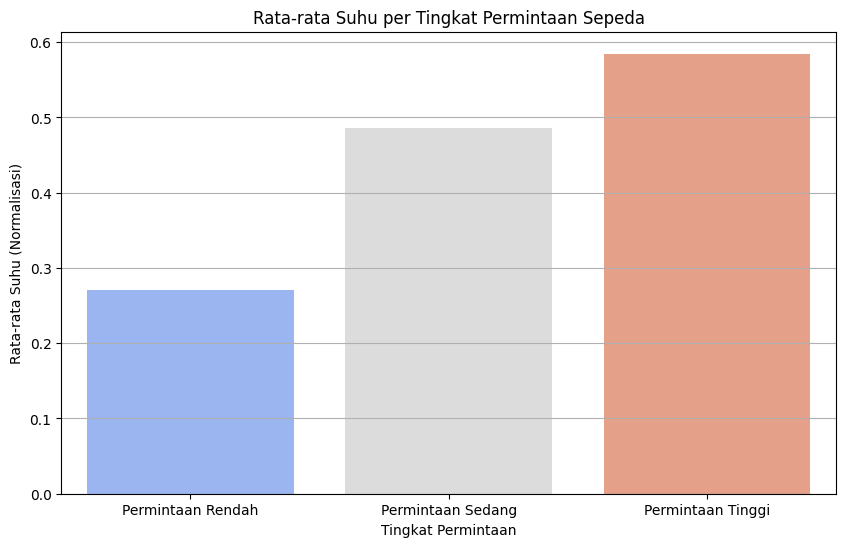

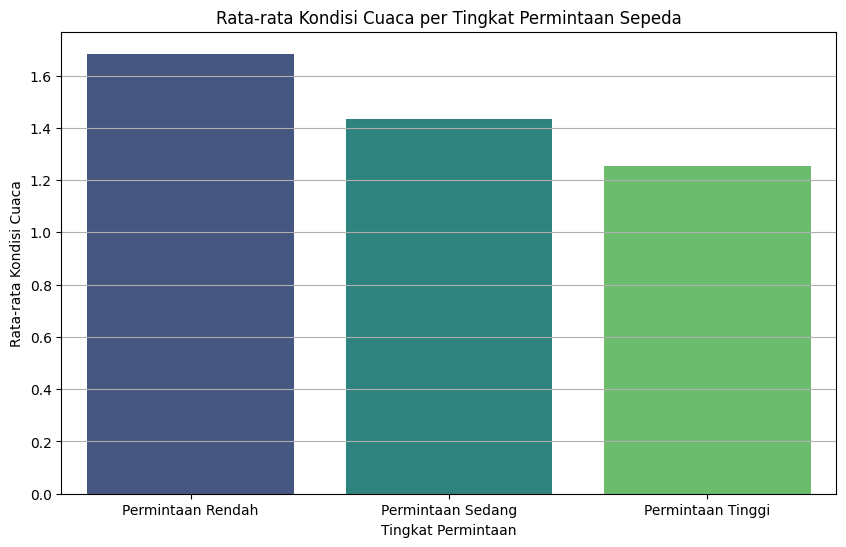

In [72]:
# Tentukan batas-batas bin untuk jumlah sewa (cnt)
# Anda bisa menyesuaikan batas ini berdasarkan distribusi data atau pemahaman bisnis
bins = [0, 2000, 5000, df_day['cnt'].max()]
labels = ['Permintaan Rendah', 'Permintaan Sedang', 'Permintaan Tinggi']

df_day['demand_level'] = pd.cut(df_day['cnt'], bins=bins, labels=labels, right=False)

# Kelompokkan data berdasarkan demand_level dan hitung rata-rata fitur relevan
demand_clusters = df_day.groupby('demand_level')[['temp', 'hum', 'windspeed', 'weathersit']].mean().reset_index()

print("Rata-rata fitur per tingkat permintaan:")
print(demand_clusters)

# Visualisasi rata-rata suhu per tingkat permintaan
plt.figure(figsize=(10, 6))
sns.barplot(x='demand_level', y='temp', data=demand_clusters, hue='demand_level', palette='coolwarm', legend=False)
plt.title('Rata-rata Suhu per Tingkat Permintaan Sepeda')
plt.xlabel('Tingkat Permintaan')
plt.ylabel('Rata-rata Suhu (Normalisasi)')
plt.grid(axis='y')
plt.show()

# Visualisasi rata-rata weathersit per tingkat permintaan
plt.figure(figsize=(10, 6))
sns.barplot(x='demand_level', y='weathersit', data=demand_clusters, hue='demand_level', palette='viridis', legend=False)
plt.title('Rata-rata Kondisi Cuaca per Tingkat Permintaan Sepeda')
plt.xlabel('Tingkat Permintaan')
plt.ylabel('Rata-rata Kondisi Cuaca')
plt.grid(axis='y')
plt.show()

**Insight dari Binning Permintaan:**
- Pada hari dengan 'Permintaan Tinggi', suhu rata-rata cenderung lebih tinggi dan kondisi cuaca rata-rata cenderung lebih baik (nilai `weathersit` lebih rendah menunjukkan cuaca lebih baik).
- Sebaliknya, 'Permintaan Rendah' terjadi pada suhu rata-rata yang lebih rendah dan kondisi cuaca yang kurang mendukung. Ini semakin menguatkan bahwa cuaca adalah pendorong utama permintaan sepeda.

## Conclusion

- **Tren Permintaan dan Pengaruh Lingkungan:** Permintaan sepeda menunjukkan pertumbuhan signifikan dari tahun 2011 ke 2012, mendukung potensi ekspansi bisnis. Kenaikan suhu secara konsisten meningkatkan permintaan, menjadikannya faktor pendorong utama. Kecepatan angin menjadi faktor penghambat minor, dengan korelasi negatif yang lemah.
- **Pola Penggunaan dan Tipe Pengguna:** Sepeda lebih banyak digunakan untuk **commuting** oleh pengguna terdaftar (hari kerja, jam sibuk pagi dan sore) dan untuk **rekreasi** oleh pengguna kasual (akhir pekan, siang hari). Permintaan mencapai puncak pada jam 8 pagi dan 5-6 sore, serta sedikit meningkat pada hari Jumat dan Sabtu.
- **Insight dari Clustering (Pengelompokan Harian):** Analisis clustering menunjukkan bahwa hari-hari dapat dikelompokkan berdasarkan kombinasi kondisi cuaca dan tingkat permintaan. Cluster dengan permintaan tertinggi memiliki suhu yang lebih tinggi dan kondisi cuaca yang sangat baik. Sebaliknya, permintaan rendah terjadi pada suhu yang lebih rendah dan kondisi cuaca yang kurang mendukung. Hal ini semakin menguatkan bahwa faktor cuaca adalah penentu utama fluktuasi permintaan sepeda.

In [73]:
df_day.to_csv("all_data_daily_processed.csv", index=False)